# Salary Prediction — End-to-End Machine Learning Project
This notebook follows the assignment workflow: data preparation, exploration, preprocessing, model training, evaluation, serialization, and preparation for Streamlit deployment.


## 1. Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

## 2. Load the Salary Dataset

In [7]:
df= pd.read_csv("https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/TBD/salary_dataset.csv")
df

,Experience Years,Salary
0,0.6,27868
1,0.6,31381
2,0.7,44204
3,0.8,39551
4,0.9,25984
...,...,...
195,14.6,158775
196,14.6,160741
197,14.6,170198
198,14.8,154396


In [10]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nDataset information:")
df.info()


Shape: (200, 2)

Data types:
Experience Years    float64
Salary                int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  200 non-null    float64
 1   Salary            200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.3 KB


## 3. Data Quality Checks

In [11]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Experience Years    0
Salary              0
dtype: int64

Duplicate rows: 0


In [12]:
# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200, 2)


## 4. Explore the Data

       Experience Years         Salary
count        200.000000     200.000000
mean           7.519000   96834.455000
std            4.279792   40938.012116
min            0.600000   25984.000000
25%            3.800000   60248.500000
50%            7.700000   94732.000000
75%           11.500000  132854.500000
max           14.800000  173265.000000


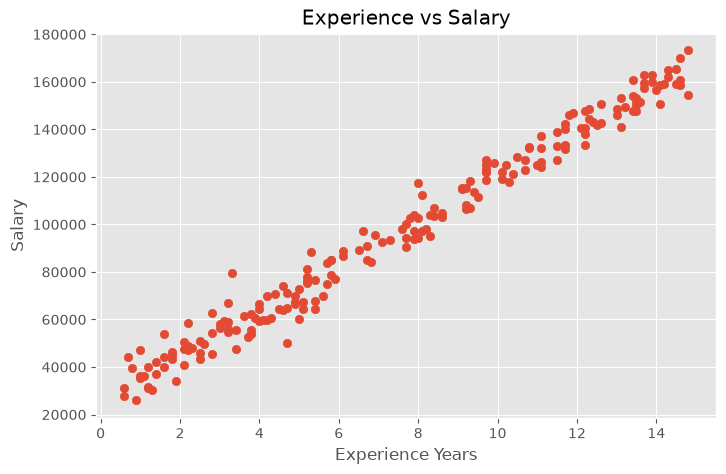

In [13]:
print(df.describe())
plt.figure(figsize=(8,5))
plt.scatter(df["Experience Years"], df["Salary"])
plt.xlabel("Experience Years")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

## 5. Select Features and Target

In [14]:
X = df[["Experience Years"]]
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 160
Testing rows: 40


## 6. Train Linear Regression Model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print(f"Intercept: {model.intercept_:,.2f}")
print(f"Coefficient: {model.coef_[0]:,.2f}")

MAE  : 4,056.34
MSE  : 23,745,684.25
RMSE : 4,872.95
R²   : 0.9831
Intercept: 25,755.15
Coefficient: 9,437.99


## 7. Actual vs Predicted Salary

In [16]:
results = pd.DataFrame({"Actual Salary": y_test.values, "Predicted Salary": y_pred})
results.head(10)


,Actual Salary,Predicted Salary
0,95688,90877.306132
1,39842,40855.938147
2,43366,49350.132710
3,140441,139954.874721
4,122264,117303.689218
5,106946,105034.297071
6,72849,72945.117609
7,146188,148449.069284
8,160947,152224.266868
9,55712,57844.327274


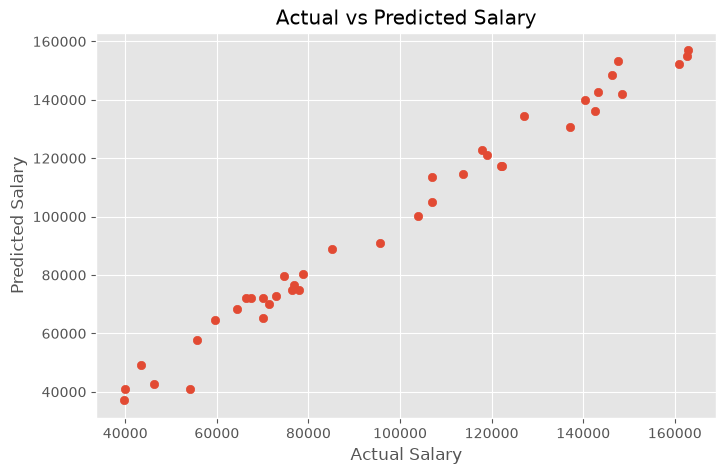

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

## 8. Save / Serialize the Trained Model

In [18]:
Path("../model").mkdir(exist_ok=True)
joblib.dump(model, "../model/salary_model.pkl")
print("Model saved to model/salary_model.pkl")

Model saved to model/salary_model.pkl


## 9. Conclusion
The project uses Years of Experience as the input feature and Salary as the target. A Linear Regression model is trained and evaluated using MAE, MSE, RMSE and R². The serialized model is then used by the Streamlit application for salary predictions without retraining each time the app starts.

## Model Serialization

In [20]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

In [21]:
with open("model.pkl", "rb") as file:
   model = pickle.load(file)


In [22]:
model.predict([[5]])

c:\Users\hp\Desktop\salary\ML_Salary_Prediction\ML_Salary_Prediction\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([72945.11760894])